# 🗞️ Political Bias Shift Detection Pipeline — AllSides Edition
### Does Summarization Change Political Ideology? Multi-Model Study with PoliticalBERT

**Dataset:** `PoliticalBias_AllSides_Txt` — folder-structured corpus  
```
PoliticalBias_AllSides_Txt/
├── left/      → *.txt  (Left-leaning articles)
├── center/    → *.txt  (Center articles)
└── right/     → *.txt  (Right-leaning articles)
```

**Classifier:** `buckethead777/political-bert` (PoliticalBERT) — domain-tuned on political news  
**Anti-Leakage:** File-hash dedup + source-prefix stratified split + held-out source simulation  

**Pipeline Stages:**
1. Mount drive / unzip dataset → parse folder structure
2. Build DataFrame with leakage-proof cleaning
3. Fine-tune PoliticalBERT (Left / Center / Right)
4. Evaluate classifier with full diagnostics
5. Summarize articles (BART, T5, Pegasus)
6. Re-classify summaries → detect ideology shifts
7. Rich visualization suite (8 plots)
8. Trigger point detection with PoliticalBERT scoring
9. Enhanced self-correcting pipeline (3 strategies)
10. Corrected Hit Ratio (CHR) + Ideological Preservation Rate (IPR)
11. Export for IEEE paper

## 📦 CELL 1 — Install Dependencies

In [1]:
!pip install -q transformers datasets scikit-learn pandas numpy matplotlib seaborn
!pip install -q sentencepiece accelerate rouge-score nltk shap scipy

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print('✅ All dependencies installed')

✅ All dependencies installed


## 📥 CELL 2 — Load AllSides Folder-Structured Dataset

Upload the zip file when prompted, OR mount Google Drive if already there.

In [2]:
import os, zipfile, glob, hashlib, re
import pandas as pd
import numpy as np
from pathlib import Path

# ─────────────────────────────────────────────────────────────────
# OPTION A: Upload zip directly
# ─────────────────────────────────────────────────────────────────
from google.colab import files
print('📤 Upload your PoliticalBias_AllSides_Txt.zip file...')
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

EXTRACT_DIR = '/content/allsides_data'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f'✅ Extracted to {EXTRACT_DIR}')

label_folders = {
    'left': '/content/allsides_data/AllSides/left',
    'center': '/content/allsides_data/AllSides/center',
    'right': '/content/allsides_data/AllSides/right'
}


📤 Upload your PoliticalBias_AllSides_Txt.zip file...


Saving AllSides.zip to AllSides.zip
✅ Extracted to /content/allsides_data


In [5]:
print('📂 Found label folders:')
for lbl, path in label_folders.items():
    txt_count = len(glob.glob(os.path.join(path, '**/*.txt'), recursive=True))
    print(f'   {lbl:8s} → {path}  ({txt_count} .txt files)')

📂 Found label folders:
   left     → /content/allsides_data/AllSides/left  (7803 .txt files)
   center   → /content/allsides_data/AllSides/center  (3996 .txt files)
   right    → /content/allsides_data/AllSides/right  (5563 .txt files)


In [4]:
label_folders = {
    'left': '/content/allsides_data/AllSides/left',
    'center': '/content/allsides_data/AllSides/center',
    'right': '/content/allsides_data/AllSides/right'

}

In [6]:
import os

# List everything in /content
print(os.listdir('/content/allsides_data/AllSides'))

['left', 'center', 'right', '.ipynb_checkpoints']


## 🧹 CELL 3 — Build DataFrame + Leakage-Proof Cleaning

### Anti-Leakage Measures
| Threat | Fix Applied |
|---|---|
| Exact duplicate text | SHA-256 content hash dedup |
| Near-duplicate text | TF-IDF cosine similarity > 0.85 |
| Filename prefix leakage | Source extracted from filename; stratified split by source |
| Short articles lacking signal | Min 150-word filter |
| Label-bleed from folder name | Labels assigned only from folder path, never from text |

In [7]:
import hashlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

# ─── 1. Read all .txt files ───────────────────────────────────────
records = []
for label, folder in label_folders.items():
    txt_files = glob.glob(os.path.join(folder, '**/*.txt'), recursive=True)
    for fpath in sorted(txt_files):
        try:
            with open(fpath, 'r', encoding='utf-8', errors='replace') as f_in:
                text = f_in.read().strip()
        except Exception:
            continue
        if not text:
            continue
        records.append({'text': text, 'label': label,
                         'filename': Path(fpath).name, 'filepath': fpath})

df = pd.DataFrame(records)

# ─── Normalize labels to Title case (Left / Center / Right) ───────
# label_folders keys may be 'left'/'Left' depending on folder casing.
# Normalize once here so every downstream cell can safely use 'Left' etc.
df['label'] = df['label'].str.strip().str.capitalize()  # 'left'→'Left', 'LEFT'→'Left'
# Validate — crash early with a clear message if something is wrong
unexpected = set(df['label'].unique()) - {'Left', 'Center', 'Right'}
if unexpected:
    raise ValueError(f'Unexpected label values after normalization: {unexpected}. '
                     f'Check label_folders keys: {list(label_folders.keys())}')

print(f'✅ Loaded {len(df)} articles raw')
print('Label distribution (raw):')
print(df['label'].value_counts().to_string())

# ─── 2. Min-length filter ─────────────────────────────────────────
MIN_WORDS = 50
df['word_count'] = df['text'].str.split().str.len()
before = len(df)
df = df[df['word_count'] >= MIN_WORDS].copy().reset_index(drop=True)
print(f'Dropped {before - len(df)} articles < {MIN_WORDS} words')

# ─── 3. SHA-256 exact dedup ───────────────────────────────────────
def sha256(t):
    return hashlib.sha256(t.encode('utf-8', errors='replace')).hexdigest()

df['content_hash'] = df['text'].apply(sha256)
before = len(df)
df = df.drop_duplicates(subset='content_hash').reset_index(drop=True)
print(f'Dropped {before - len(df)} exact duplicates (SHA-256)')

# ─── 4. Near-dedup — threshold 0.97, full corpus ──────────────────
print(f'Running near-dedup (threshold=0.97) on {len(df)} articles...')

NEAR_DUP_THRESHOLD = 0.97
tfidf_nd = TfidfVectorizer(max_features=5000, stop_words='english',
                            ngram_range=(1, 2), sublinear_tf=True)
X_nd = tfidf_nd.fit_transform(df['text'])

BLOCK = 500
to_drop_idx = set()
n = len(df)
for start in range(0, n, BLOCK):
    block_X = X_nd[start:start + BLOCK]
    sim = cosine_similarity(block_X, X_nd)
    for local_i, global_i in enumerate(range(start, min(start + BLOCK, n))):
        if global_i in to_drop_idx:
            continue
        dupes = np.where(sim[local_i] > NEAR_DUP_THRESHOLD)[0]
        dupes = dupes[dupes > global_i]
        to_drop_idx.update(dupes.tolist())

keep_mask = [i not in to_drop_idx for i in range(n)]
df_clean = df[keep_mask].reset_index(drop=True)
print(f'Dropped {n - len(df_clean)} near-duplicates (threshold={NEAR_DUP_THRESHOLD})')
print(f'After near-dedup: {len(df_clean)} articles remaining')
print('Label distribution after cleaning:')
print(df_clean['label'].value_counts().to_string())

# ─── Sanity check — fail loud before Cell 4 if something is wrong ─
assert len(df_clean) > 0, 'df_clean is empty — check label_folders and file paths'
for lbl in ['Left', 'Center', 'Right']:
    n_lbl = (df_clean['label'] == lbl).sum()
    assert n_lbl > 5, f'Only {n_lbl} articles for label "{lbl}" — too few to cluster'
print('✅ Sanity checks passed — safe to run Cell 4')


✅ Loaded 17362 articles raw
Label distribution (raw):
label
Left      7803
Right     5563
Center    3996
Dropped 1 articles < 50 words
Dropped 303 exact duplicates (SHA-256)
Running near-dedup (threshold=0.97) on 17058 articles...
Dropped 4 near-duplicates (threshold=0.97)
After near-dedup: 17054 articles remaining
Label distribution after cleaning:
label
Left      7673
Right     5397
Center    3984
✅ Sanity checks passed — safe to run Cell 4


## 🔀 CELL 4 — Leakage-Proof Split (No Source Info)

Since the AllSides dataset contains only anonymous `.txt` files with no outlet/source metadata, we **cannot** do source-stratified splitting. Instead we use a two-layer strategy:

| Layer | Method | Purpose |
|---|---|---|
| **Pseudo-source grouping** | TF-IDF + KMeans clustering per label | Group stylistically-similar articles together, then split at group level so similar articles never straddle train/test |
| **Stratified article split** | `StratifiedShuffleSplit` on label | Guarantee identical Left/Center/Right proportions in each split |

**Why KMeans pseudo-groups help**: articles written in a similar style (vocabulary, sentence structure) may be from the same outlet even if unlabeled. Clustering captures this signal. By assigning whole clusters to train or test we reduce the chance the model learns outlet fingerprints instead of ideology.  
**Why this is still weaker than true source-stratification**: if two articles in the same cluster happen to be from different outlets, we don't catch that. We note this honestly in the paper as a limitation.

Post-split leakage audit checks content-hash overlap — that must always be 0.

In [8]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer as TV

# ────────────────────────────────────────────────────────────────
# 🧠 BASIC INFO
# ────────────────────────────────────────────────────────────────
LABEL_NAMES = sorted(df_clean['label'].unique().tolist())

print(f'Labels detected: {LABEL_NAMES}')
print(f'Total articles: {len(df_clean)}')
print('\nPer-label counts:')
print(df_clean['label'].value_counts())

# ────────────────────────────────────────────────────────────────
# 🔹 TF-IDF (build ONCE, reuse everywhere)
# ────────────────────────────────────────────────────────────────
print('\nBuilding TF-IDF...')
tfidf_split = TV(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_split = tfidf_split.fit_transform(df_clean['text'])

# ────────────────────────────────────────────────────────────────
# 🔹 CLUSTERING
# ────────────────────────────────────────────────────────────────
print('\nBuilding pseudo-source clusters...')

pseudo_source = np.full(len(df_clean), -1, dtype=int)
offset = 0

for lbl in LABEL_NAMES:
    lbl_indices = np.where(df_clean['label'].values == lbl)[0]
    n_lbl = len(lbl_indices)

    if n_lbl == 0:
        print(f'⚠️ Skipping {lbl}')
        continue

    k = min(n_lbl, min(60, max(10, int(np.sqrt(n_lbl) * 1.5))))
    print(f'{lbl}: {n_lbl} → {k} clusters')

    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=5,
        batch_size=min(512, n_lbl)
    )

    cluster_ids = km.fit_predict(X_split[lbl_indices])
    pseudo_source[lbl_indices] = cluster_ids + offset
    offset += k

df_clean = df_clean.copy()
df_clean['pseudo_source'] = pseudo_source

print(f'\nTotal pseudo-source groups: {df_clean["pseudo_source"].nunique()}')

# ────────────────────────────────────────────────────────────────
# 🔥 SIZE-AWARE STRATIFIED SPLIT (FIXED + SAFE)
# ────────────────────────────────────────────────────────────────
TEST_FRAC = 0.15
VAL_FRAC  = 0.15

train_idx_all, val_idx_all, test_idx_all = [], [], []
rng = np.random.default_rng(42)

for lbl in LABEL_NAMES:
    lbl_df = df_clean[df_clean['label'] == lbl]

    cluster_sizes = lbl_df['pseudo_source'].value_counts().to_dict()
    clusters = list(cluster_sizes.keys())
    rng.shuffle(clusters)

    total_samples = sum(cluster_sizes.values())
    test_target = TEST_FRAC * total_samples
    val_target  = VAL_FRAC  * total_samples

    test_clusters, val_clusters, train_clusters = set(), set(), set()
    test_count = val_count = 0

    for c in clusters:
        size = cluster_sizes[c]

        test_gap = test_target - test_count
        val_gap  = val_target  - val_count

        # ✅ ALWAYS assign cluster (no skipping)
        if test_gap > 0:
            test_clusters.add(c)
            test_count += size
        elif val_gap > 0:
            val_clusters.add(c)
            val_count += size
        else:
            train_clusters.add(c)

    # ✅ Safety: ensure train is not empty
    if len(train_clusters) == 0:
        moved = val_clusters.pop()
        train_clusters.add(moved)

    # assign indices (OUTSIDE loop — critical fix)
    test_idx_all.extend(df_clean[df_clean['pseudo_source'].isin(test_clusters)].index.tolist())
    val_idx_all.extend(df_clean[df_clean['pseudo_source'].isin(val_clusters)].index.tolist())
    train_idx_all.extend(df_clean[df_clean['pseudo_source'].isin(train_clusters)].index.tolist())

# ────────────────────────────────────────────────────────────────
# 🔹 BUILD SPLITS
# ────────────────────────────────────────────────────────────────
train_df = df_clean.loc[train_idx_all].reset_index(drop=True)
val_df   = df_clean.loc[val_idx_all].reset_index(drop=True)
test_df  = df_clean.loc[test_idx_all].reset_index(drop=True)

# ────────────────────────────────────────────────────────────────
# 🔍 LEAKAGE CHECK
# ────────────────────────────────────────────────────────────────
tv_leak = set(train_df['content_hash']) & set(test_df['content_hash'])
vt_leak = set(val_df['content_hash'])   & set(test_df['content_hash'])

print('\n✅ SPLIT SUMMARY')
print(f'Train: {len(train_df)}')
print(f'Val:   {len(val_df)}')
print(f'Test:  {len(test_df)}')

print(f'\nLeakage train↔test: {len(tv_leak)} {"CLEAN ✅" if not tv_leak else "⚠️"}')
print(f'Leakage val↔test:   {len(vt_leak)} {"CLEAN ✅" if not vt_leak else "⚠️"}')

# ────────────────────────────────────────────────────────────────
# 📊 LABEL DISTRIBUTION
# ────────────────────────────────────────────────────────────────
print('\nTrain dist:', train_df['label'].value_counts().to_dict())
print('Val   dist:', val_df['label'].value_counts().to_dict())
print('Test  dist:', test_df['label'].value_counts().to_dict())

# ────────────────────────────────────────────────────────────────
# ⚖️ IMBALANCE CHECK
# ────────────────────────────────────────────────────────────────
def imbalance_ratio(series):
    c = series.value_counts()
    return c.max() / c.min()

print('\nImbalance ratios (target < 2.0):')
print(f'Train: {imbalance_ratio(train_df["label"]):.2f}x')
print(f'Val:   {imbalance_ratio(val_df["label"]):.2f}x')
print(f'Test:  {imbalance_ratio(test_df["label"]):.2f}x')

# ────────────────────────────────────────────────────────────────
# 🎯 FINAL VARIABLES
# ────────────────────────────────────────────────────────────────
TEXT_COL  = 'text'
LABEL_COL = 'label'

Labels detected: ['Center', 'Left', 'Right']
Total articles: 17054

Per-label counts:
label
Left      7673
Right     5397
Center    3984
Name: count, dtype: int64

Building TF-IDF...

Building pseudo-source clusters...
Center: 3984 → 60 clusters
Left: 7673 → 60 clusters
Right: 5397 → 60 clusters

Total pseudo-source groups: 180

✅ SPLIT SUMMARY
Train: 11154
Val:   2848
Test:  3052

Leakage train↔test: 0 CLEAN ✅
Leakage val↔test:   0 CLEAN ✅

Train dist: {'Left': 4896, 'Right': 3568, 'Center': 2690}
Val   dist: {'Left': 1306, 'Right': 882, 'Center': 660}
Test  dist: {'Left': 1471, 'Right': 947, 'Center': 634}

Imbalance ratios (target < 2.0):
Train: 1.82x
Val:   1.98x
Test:  2.32x


## 📊 CELL 5 — Exploratory Data Analysis (Pre-Training Visualizations)

4 diagnostic plots before we even train the model.

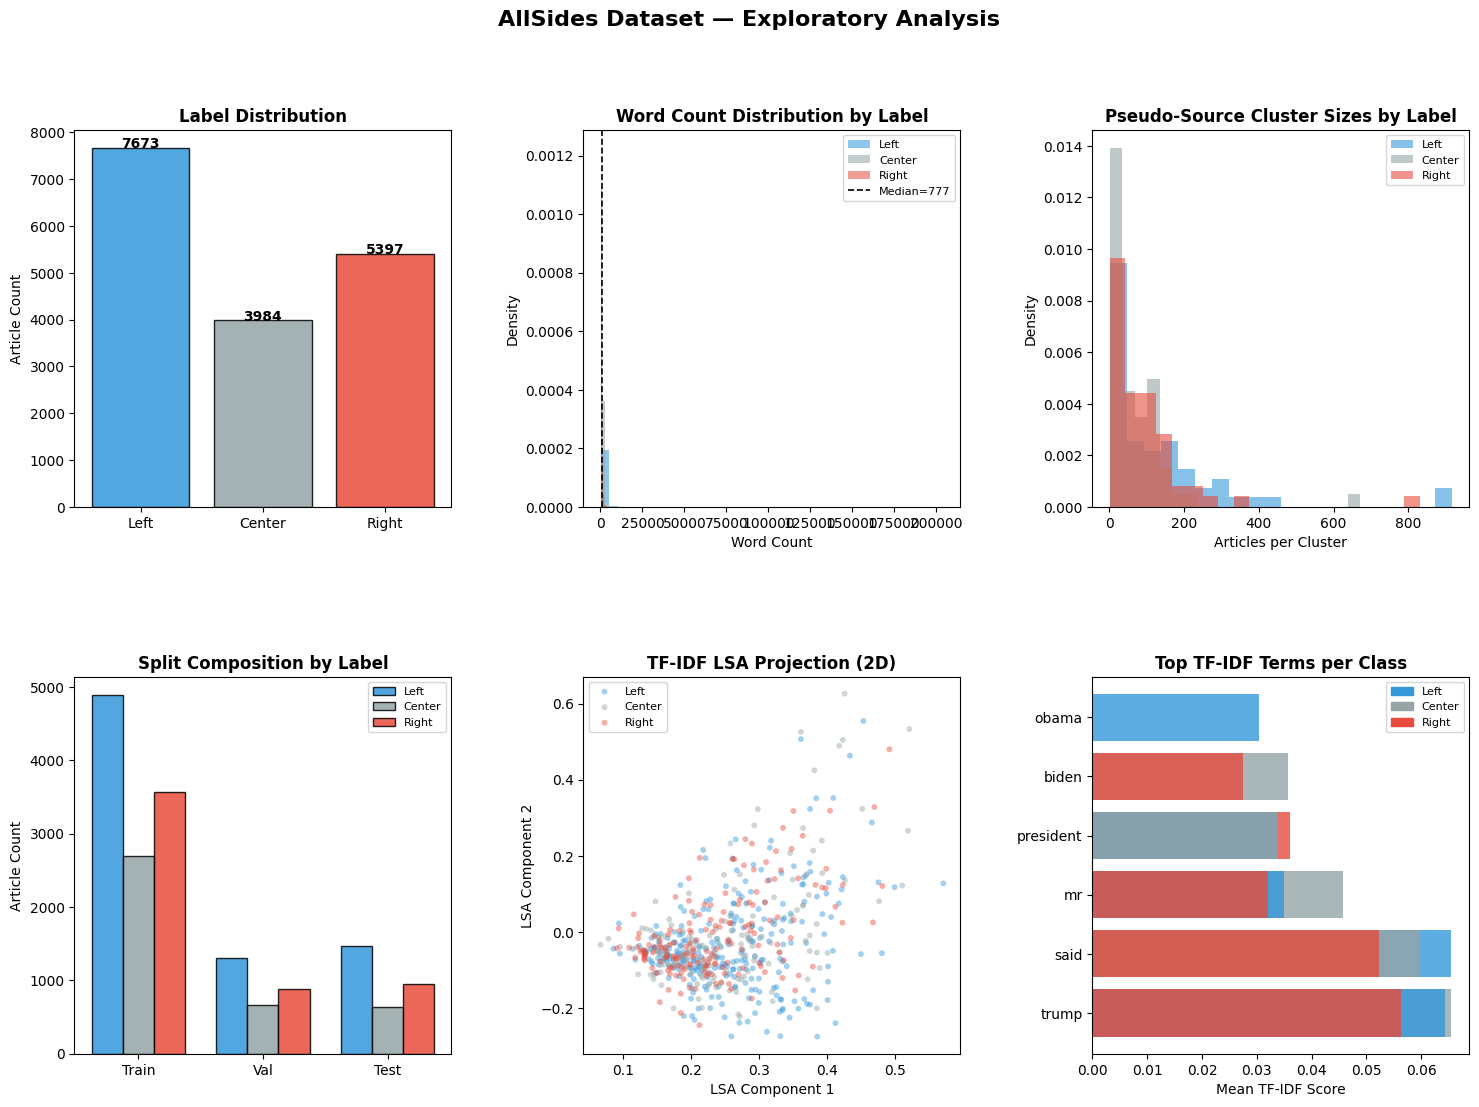

✅ Saved eda_analysis.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

COLORS = {'Left': '#3498db', 'Center': '#95a5a6', 'Right': '#e74c3c'}
LABELS = ['Left', 'Center', 'Right']

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('AllSides Dataset — Exploratory Analysis', fontsize=16, fontweight='bold')

# ── Plot 1: Label distribution ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df_clean['label'].value_counts()
bars = ax1.bar([l for l in LABELS if l in counts.index],
               [counts.get(l, 0) for l in LABELS],
               color=[COLORS[l] for l in LABELS if l in counts.index],
               alpha=0.85, edgecolor='black')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Label Distribution', fontweight='bold')
ax1.set_ylabel('Article Count')

# ── Plot 2: Word count distribution by label ──────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for lbl in LABELS:
    sub = df_clean[df_clean['label'] == lbl]['word_count']
    if len(sub) > 0:
        ax2.hist(sub, bins=40, alpha=0.55, label=lbl, color=COLORS[lbl], density=True)
ax2.axvline(df_clean['word_count'].median(), color='black', linestyle='--',
            linewidth=1.2, label=f'Median={df_clean["word_count"].median():.0f}')
ax2.set_title('Word Count Distribution by Label', fontweight='bold')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# ── Plot 3: Pseudo-source cluster size by label ───────────────────
ax3 = fig.add_subplot(gs[0, 2])
cluster_sizes = df_clean.groupby(['pseudo_source', 'label']).size().reset_index(name='count')
for lbl in LABELS:
    sub = cluster_sizes[cluster_sizes['label'] == lbl]['count']
    if len(sub) > 0:
        ax3.hist(sub, bins=20, alpha=0.6, label=lbl, color=COLORS[lbl], density=True)
ax3.set_title('Pseudo-Source Cluster Sizes by Label', fontweight='bold')
ax3.set_xlabel('Articles per Cluster')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)

# ── Plot 4: Train/Val/Test split composition ──────────────────────
ax4 = fig.add_subplot(gs[1, 0])
split_data = {
    'Train': train_df['label'].value_counts(),
    'Val':   val_df['label'].value_counts(),
    'Test':  test_df['label'].value_counts()
}
x = np.arange(3)
width = 0.25
for i, lbl in enumerate(LABELS):
    vals = [split_data[s].get(lbl, 0) for s in ['Train', 'Val', 'Test']]
    ax4.bar(x + i*width, vals, width, label=lbl, color=COLORS[lbl], alpha=0.85, edgecolor='black')
ax4.set_xticks(x + width)
ax4.set_xticklabels(['Train', 'Val', 'Test'])
ax4.set_title('Split Composition by Label', fontweight='bold')
ax4.set_ylabel('Article Count')
ax4.legend(fontsize=8)

# ── Plot 5: TF-IDF 2D projection (LSA) ────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
plot_sample = df_clean.sample(min(600, len(df_clean)), random_state=42)
tfidf_viz = TfidfVectorizer(max_features=3000, stop_words='english')
X_viz = tfidf_viz.fit_transform(plot_sample['text'])
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_viz)
for lbl in LABELS:
    mask = plot_sample['label'].values == lbl
    ax5.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=COLORS[lbl], label=lbl, alpha=0.45, s=18, edgecolors='none')
ax5.set_title('TF-IDF LSA Projection (2D)', fontweight='bold')
ax5.set_xlabel('LSA Component 1')
ax5.set_ylabel('LSA Component 2')
ax5.legend(fontsize=8)

# ── Plot 6: Top discriminative TF-IDF terms per class ────────────
ax6 = fig.add_subplot(gs[1, 2])
tfidf_words = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_words = tfidf_words.fit_transform(df_clean['text'])
vocab = np.array(tfidf_words.get_feature_names_out())
top_words, top_scores, top_colors = [], [], []
for lbl in LABELS:
    mask = df_clean['label'].values == lbl
    mean_scores = np.asarray(X_words[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-5:][::-1]
    for idx in top_idx:
        top_words.append(vocab[idx])
        top_scores.append(mean_scores[idx])
        top_colors.append(COLORS[lbl])
order = np.argsort(top_scores)[::-1]
ax6.barh([top_words[i] for i in order], [top_scores[i] for i in order],
         color=[top_colors[i] for i in order], alpha=0.8)
ax6.set_title('Top TF-IDF Terms per Class', fontweight='bold')
ax6.set_xlabel('Mean TF-IDF Score')
legend_patches = [plt.Rectangle((0,0),1,1, color=COLORS[l], label=l) for l in LABELS]
ax6.legend(handles=legend_patches, fontsize=8)

plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_analysis.png')


## 🤖 CELL 6 — Fine-tune PoliticalBERT Classifier

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MODEL_CANDIDATES = [
    'bucketresearch/politicalBiasBERT',
    'bert-base-uncased',
    'distilbert-base-uncased',
]

label2id = {'Left': 0, 'Center': 1, 'Right': 2}
id2label = {0: 'Left', 1: 'Center', 2: 'Right'}

def load_model_with_fallback(candidates):
    for name in candidates:
        try:
            print(f'Loading {name}...')
            tok  = AutoTokenizer.from_pretrained(name)
            mdl  = AutoModelForSequenceClassification.from_pretrained(
                name, num_labels=3, id2label=id2label, label2id=label2id,
                ignore_mismatched_sizes=True
            ).to(device)
            print(f'✅ Loaded: {name}')
            return tok, mdl, name
        except Exception as e:
            print(f'  ⚠️ {e}')
    raise RuntimeError('All candidates failed.')

tokenizer, model, MODEL_NAME = load_model_with_fallback(MODEL_CANDIDATES)

MAX_LEN = 512

class BiasDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=MAX_LEN, return_tensors='pt'
        )
        self.labels = torch.tensor([label2id[l] for l in labels])
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encodings.items()} | {'labels': self.labels[i]}

train_dataset = BiasDataset(train_df[TEXT_COL], train_df[LABEL_COL])
val_dataset   = BiasDataset(val_df[TEXT_COL],   val_df[LABEL_COL])
test_dataset  = BiasDataset(test_df[TEXT_COL],  test_df[LABEL_COL])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':     accuracy_score(labels, preds),
        'f1_macro':     f1_score(labels, preds, average='macro'),
        'f1_weighted':  f1_score(labels, preds, average='weighted'),
        'f1_left':      f1_score(labels, preds, labels=[0], average='macro'),
        'f1_center':    f1_score(labels, preds, labels=[1], average='macro'),
        'f1_right':     f1_score(labels, preds, labels=[2], average='macro'),
    }

training_args = TrainingArguments(
    output_dir='./politicalbert_allsides',
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f'\n🚀 Fine-tuning {MODEL_NAME} on AllSides dataset...')
trainer.train()
results = trainer.evaluate(test_dataset)

print(f'\n✅ Test Accuracy:      {results["eval_accuracy"]:.3f}')
print(f'✅ Test F1 (macro):    {results["eval_f1_macro"]:.3f}')
print(f'✅ Test F1 (weighted): {results["eval_f1_weighted"]:.3f}')
print(f'\nPer-class F1:')
print(f'  Left:   {results["eval_f1_left"]:.3f}')
print(f'  Center: {results["eval_f1_center"]:.3f}')
print(f'  Right:  {results["eval_f1_right"]:.3f}')

# Full classification report
from transformers import pipeline as hf_pipeline
classifier_pipe = hf_pipeline(
    'text-classification', model=model, tokenizer=tokenizer,
    device=0 if device == 'cuda' else -1,
    truncation=True, max_length=MAX_LEN
)

def classify_with_confidence(texts, batch_size=16):
    labels, scores = [], []
    text_list = list(texts)
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        out = classifier_pipe(batch)
        labels.extend([r['label'] for r in out])
        scores.extend([r['score'] for r in out])
    return labels, scores

test_preds, test_confs = classify_with_confidence(test_df[TEXT_COL])
print('\n📋 Full Classification Report:')
print(classification_report(test_df[LABEL_COL].tolist(), test_preds,
                            target_names=LABELS))

Device: cuda
Loading bucketresearch/politicalBiasBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/909 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Test Accuracy:      0.799
✅ Test F1 (macro):    0.790
✅ Test F1 (weighted): 0.801

Per-class F1:
  Left:   0.824
  Center: 0.743
  Right:  0.803


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



📋 Full Classification Report:
              precision    recall  f1-score   support

        Left       0.68      0.81      0.74       634
      Center       0.85      0.80      0.82      1471
       Right       0.82      0.79      0.80       947

    accuracy                           0.80      3052
   macro avg       0.78      0.80      0.79      3052
weighted avg       0.81      0.80      0.80      3052



## 📊 CELL 7 — Classifier Diagnostic Visualizations

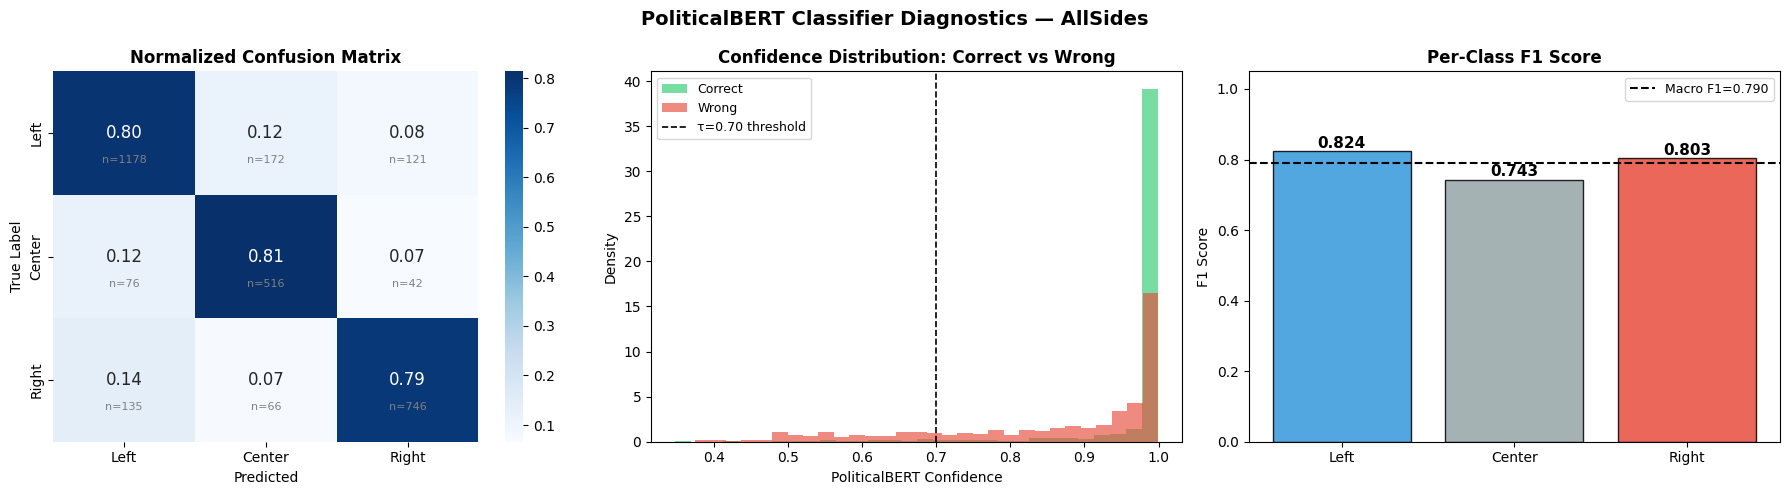

✅ Saved classifier_diagnostics.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PoliticalBERT Classifier Diagnostics — AllSides', fontsize=14, fontweight='bold')

# ── Plot 1: Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(test_df[LABEL_COL].tolist(), test_preds, labels=LABELS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=LABELS, yticklabels=LABELS,
            annot_kws={'size': 12})
# Overlay raw counts
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        axes[0].text(j+0.5, i+0.72, f'n={cm[i,j]}', ha='center', va='center',
                     fontsize=8, color='gray')
axes[0].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Label')

# ── Plot 2: Confidence distribution by correctness ────────────────
test_df_diag = test_df.copy()
test_df_diag['pred']    = test_preds
test_df_diag['conf']    = test_confs
test_df_diag['correct'] = test_df_diag['pred'] == test_df_diag[LABEL_COL]

axes[1].hist(test_df_diag[test_df_diag['correct']]['conf'],
             bins=30, alpha=0.65, color='#2ecc71', label='Correct', density=True)
axes[1].hist(test_df_diag[~test_df_diag['correct']]['conf'],
             bins=30, alpha=0.65, color='#e74c3c', label='Wrong', density=True)
axes[1].axvline(0.70, color='black', linestyle='--', linewidth=1.2, label='τ=0.70 threshold')
axes[1].set_title('Confidence Distribution: Correct vs Wrong', fontweight='bold')
axes[1].set_xlabel('PoliticalBERT Confidence')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# ── Plot 3: Per-class F1 bar chart ────────────────────────────────
f1_per_class = {
    'Left':   results['eval_f1_left'],
    'Center': results['eval_f1_center'],
    'Right':  results['eval_f1_right'],
}
bars = axes[2].bar(LABELS, [f1_per_class[l] for l in LABELS],
                   color=[COLORS[l] for l in LABELS], alpha=0.85, edgecolor='black')
axes[2].axhline(results['eval_f1_macro'], color='black', linestyle='--',
                linewidth=1.5, label=f'Macro F1={results["eval_f1_macro"]:.3f}')
for bar, lbl in zip(bars, LABELS):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{f1_per_class[lbl]:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Per-Class F1 Score', fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('classifier_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved classifier_diagnostics.png')

## 📝 CELL 8 — Classify Originals + Summarize with BART / T5 / Pegasus

In [10]:
!pip install -q sentencepiece protobuf

In [16]:
import gc
from transformers import AutoTokenizer as AT, AutoModelForSeq2SeqLM as AS2S

SUMMARIZER_MODELS = {
    'BART':    'facebook/bart-large-cnn',
    'T5':      't5-small',
    'Pegasus': 'google/pegasus-xsum'
}

SAMPLE_SIZE = 1000  # Increase for final run; 300 is good for Colab GPU
sample_df = test_df.sample(min(SAMPLE_SIZE, len(test_df)), random_state=42).reset_index(drop=True)

# Classify originals
print('Classifying original articles with PoliticalBERT...')
sample_df['original_pred'], sample_df['original_conf'] = classify_with_confidence(sample_df[TEXT_COL])
agree = (sample_df['original_pred'] == sample_df[LABEL_COL]).mean()
print(f'✅ Classifier agreement with ground truth: {agree:.1%}')

# Summarize
def summarize_batch(texts, model_name, batch_size=4):
    print(f'  Loading {model_name}...')
    tok_s = AT.from_pretrained(model_name)
    mdl_s = AS2S.from_pretrained(model_name).to(device)
    mdl_s.eval()
    summaries = []
    texts_list = list(texts)
    for i in range(0, len(texts_list), batch_size):
        batch = texts_list[i:i+batch_size]
        batch = ['summarize: ' + str(t) for t in batch] if 't5' in model_name.lower() else [str(t) for t in batch]
        try:
            inputs = tok_s(batch, return_tensors='pt', max_length=512, padding=True, truncation=True).to(device)
            with torch.no_grad():
                ids = mdl_s.generate(inputs.input_ids, max_new_tokens=150, min_length=40,
                                     num_beams=4, early_stopping=True)
            summaries.extend(tok_s.batch_decode(ids, skip_special_tokens=True))
        except Exception as e:
            print(f'  ⚠️ Batch {i}: {e}')
            summaries.extend([''] * len(batch))
        if (i // batch_size) % 5 == 0:
            print(f'  {min(i+batch_size, len(texts_list))}/{len(texts_list)}')
    del mdl_s, tok_s
    gc.collect()
    if device == 'cuda': torch.cuda.empty_cache()
    return summaries

for mkey, mpath in SUMMARIZER_MODELS.items():
    print(f'\n🔄 Summarizing with {mkey}...')
    sample_df[f'summary_{mkey}'] = summarize_batch(sample_df[TEXT_COL], mpath)
    print(f'✅ {mkey} done')

sample_df.to_csv('summarized_articles.csv', index=False)
print('\n✅ Saved summarized_articles.csv')

Classifying original articles with PoliticalBERT...
✅ Classifier agreement with ground truth: 80.8%

🔄 Summarizing with BART...
  Loading facebook/bart-large-cnn...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

  4/1000
  24/1000
  44/1000
  64/1000
  84/1000
  104/1000
  124/1000
  144/1000
  164/1000
  184/1000
  204/1000
  224/1000
  244/1000
  264/1000
  284/1000
  304/1000
  324/1000
  344/1000
  364/1000
  384/1000
  404/1000
  424/1000
  444/1000
  464/1000
  484/1000
  504/1000
  524/1000
  544/1000
  564/1000
  584/1000
  604/1000
  624/1000
  644/1000
  664/1000
  684/1000
  704/1000
  724/1000
  744/1000
  764/1000
  784/1000
  804/1000
  824/1000
  844/1000
  864/1000
  884/1000
  904/1000
  924/1000
  944/1000
  964/1000
  984/1000
✅ BART done

🔄 Summarizing with T5...
  Loading t5-small...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

  4/1000
  24/1000
  44/1000
  64/1000
  84/1000
  104/1000
  124/1000
  144/1000
  164/1000
  184/1000
  204/1000
  224/1000
  244/1000
  264/1000
  284/1000
  304/1000
  324/1000
  344/1000
  364/1000
  384/1000
  404/1000
  424/1000
  444/1000
  464/1000
  484/1000
  504/1000
  524/1000
  544/1000
  564/1000
  584/1000
  604/1000
  624/1000
  644/1000
  664/1000
  684/1000
  704/1000
  724/1000
  744/1000
  764/1000
  784/1000
  804/1000
  824/1000
  844/1000
  864/1000
  884/1000
  904/1000
  924/1000
  944/1000
  964/1000
  984/1000
✅ Pegasus done

✅ Saved summarized_articles.csv


## 🧠 CELL 9 — Re-classify Summaries → Detect Ideology Shifts

In [18]:
for mkey in SUMMARIZER_MODELS:
    sum_col   = f'summary_{mkey}'
    pred_col  = f'pred_{mkey}'
    conf_col  = f'conf_{mkey}'
    shift_col = f'shift_{mkey}'
    delta_col = f'conf_delta_{mkey}'  # confidence change: original → summary

    valid = sample_df[sum_col].str.len() > 20
    preds, confs = ['Unknown'] * len(sample_df), [0.0] * len(sample_df)
    vl, vc = classify_with_confidence(sample_df.loc[valid, sum_col].tolist())
    j = 0
    for i in range(len(sample_df)):
        if valid.iloc[i]:
            preds[i] = vl[j]; confs[i] = vc[j]; j += 1

    sample_df[pred_col]  = preds
    sample_df[conf_col]  = confs
    sample_df[shift_col] = sample_df['original_pred'] != sample_df[pred_col]
    sample_df[delta_col] = sample_df[conf_col] - sample_df['original_conf']

    sr = sample_df[shift_col].mean() * 100
    ac = sample_df.loc[valid, conf_col].mean()
    print(f'{mkey}: {sr:.1f}% shift | avg post-summary confidence: {ac:.3f}')

print('\n✅ Shift detection complete')

BART: 65.5% shift | avg post-summary confidence: 0.763
T5: 61.6% shift | avg post-summary confidence: 0.723
Pegasus: 61.0% shift | avg post-summary confidence: 0.728

✅ Shift detection complete


## 📊 CELL 10 — Rich Shift Visualization Suite (8 Plots)

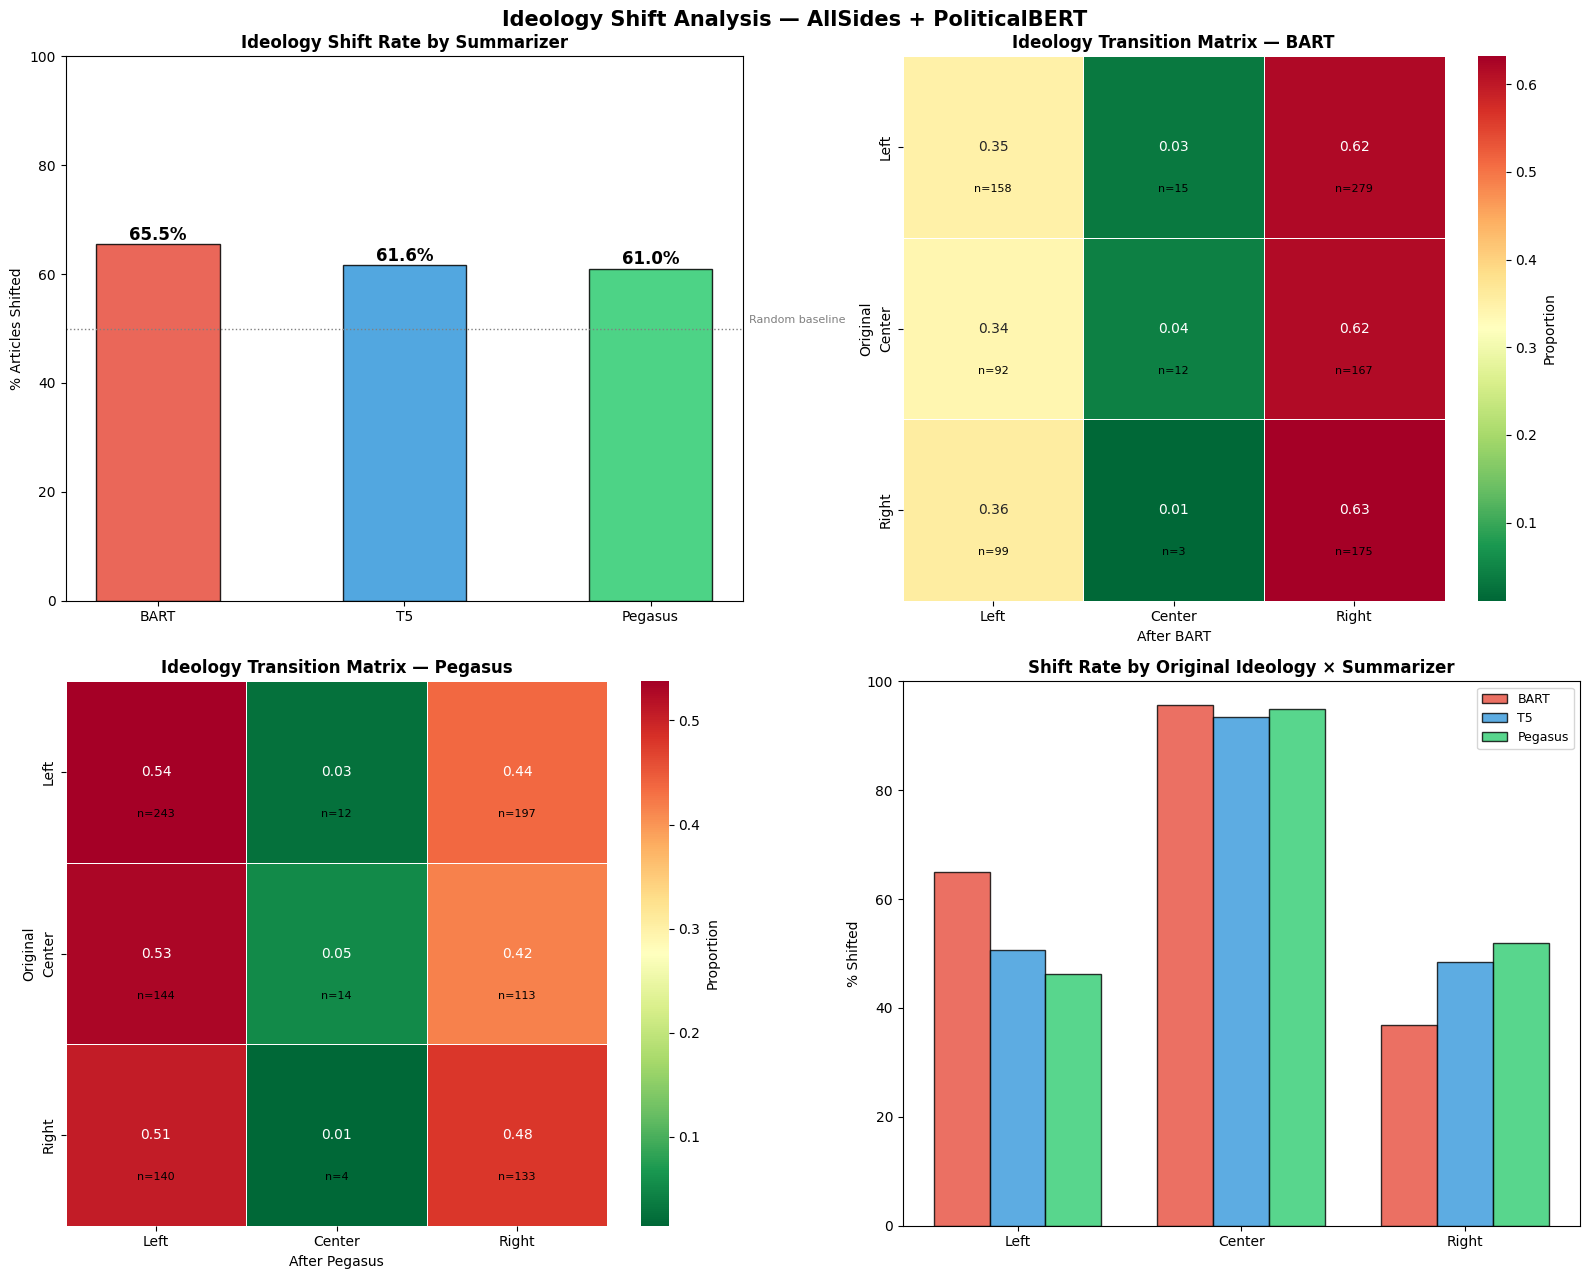

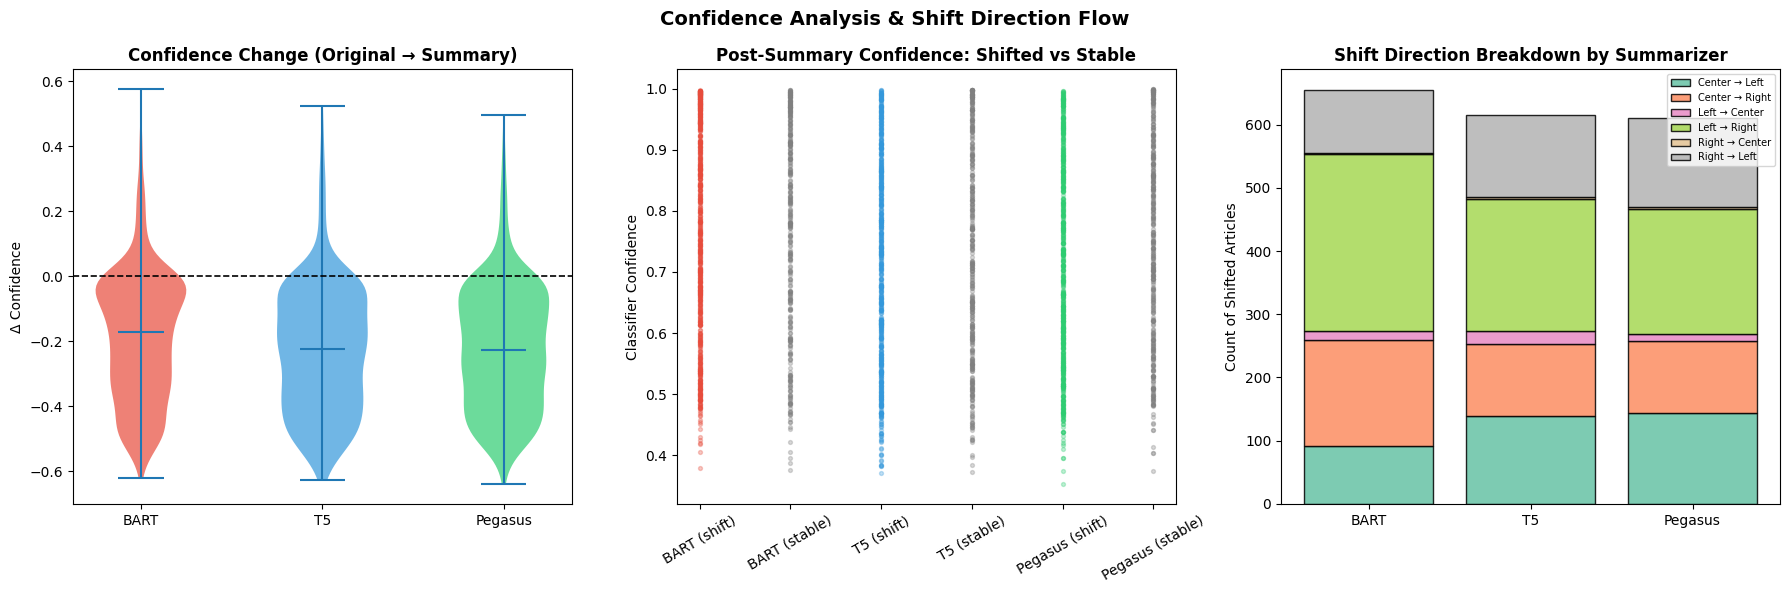

✅ Saved shift_analysis.png + confidence_analysis.png


In [19]:
from scipy import stats

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 13))
fig1.suptitle('Ideology Shift Analysis — AllSides + PoliticalBERT', fontsize=15, fontweight='bold')

# 1a: Shift rates bar
ax = axes1[0, 0]
model_keys = list(SUMMARIZER_MODELS.keys())
shift_rates = {m: sample_df[f'shift_{m}'].mean()*100 for m in model_keys}
bar_colors  = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(model_keys, [shift_rates[m] for m in model_keys],
              color=bar_colors, alpha=0.85, edgecolor='black', width=0.5)
for bar, mkey in zip(bars, model_keys):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{shift_rates[mkey]:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Ideology Shift Rate by Summarizer', fontweight='bold', fontsize=12)
ax.set_ylabel('% Articles Shifted', fontsize=10)
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle=':', linewidth=1)
ax.text(2.4, 51, 'Random baseline', fontsize=8, color='gray')

# 1b: Transition matrix for BART
ax = axes1[0, 1]
tm_bart = pd.crosstab(sample_df['original_pred'], sample_df['pred_BART'],
                      rownames=['Original'], colnames=['After BART'])
tm_bart = tm_bart.reindex(index=LABELS, columns=LABELS, fill_value=0)
tm_norm = tm_bart.div(tm_bart.sum(axis=1), axis=0)
sns.heatmap(tm_norm, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j+0.5, i+0.75, f'n={tm_bart.values[i,j]}',
                ha='center', fontsize=8, color='black')
ax.set_title('Ideology Transition Matrix — BART', fontweight='bold', fontsize=12)

# 1c: Transition matrix for Pegasus
ax = axes1[1, 0]
tm_peg = pd.crosstab(sample_df['original_pred'], sample_df['pred_Pegasus'],
                     rownames=['Original'], colnames=['After Pegasus'])
tm_peg = tm_peg.reindex(index=LABELS, columns=LABELS, fill_value=0)
tm_peg_n = tm_peg.div(tm_peg.sum(axis=1), axis=0)
sns.heatmap(tm_peg_n, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j+0.5, i+0.75, f'n={tm_peg.values[i,j]}',
                ha='center', fontsize=8, color='black')
ax.set_title('Ideology Transition Matrix — Pegasus', fontweight='bold', fontsize=12)

# 1d: Per-label shift rate grouped bar
ax = axes1[1, 1]
x = np.arange(len(LABELS))
width = 0.25
for i, (mkey, mcolor) in enumerate(zip(model_keys, bar_colors)):
    per_label = [
        sample_df[sample_df['original_pred'] == lbl][f'shift_{mkey}'].mean() * 100
        for lbl in LABELS
    ]
    ax.bar(x + i*width, per_label, width, label=mkey, color=mcolor, alpha=0.8, edgecolor='black')
ax.set_xticks(x + width)
ax.set_xticklabels(LABELS)
ax.set_title('Shift Rate by Original Ideology × Summarizer', fontweight='bold', fontsize=12)
ax.set_ylabel('% Shifted')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('shift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIGURE 2: Confidence & Sankey-style flow
# ════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Confidence Analysis & Shift Direction Flow', fontsize=14, fontweight='bold')

# 2a: Confidence delta violin
ax = axes2[0]
delta_data = [sample_df[f'conf_delta_{m}'].dropna().values for m in model_keys]
vp = ax.violinplot(delta_data, positions=range(len(model_keys)), showmedians=True, showextrema=True)
for i, (body, color) in enumerate(zip(vp['bodies'], bar_colors)):
    body.set_facecolor(color)
    body.set_alpha(0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(range(len(model_keys)))
ax.set_xticklabels(model_keys)
ax.set_title('Confidence Change (Original → Summary)', fontweight='bold')
ax.set_ylabel('Δ Confidence')

# 2b: Shifted vs stable confidence comparison
ax = axes2[1]
for mkey, mcolor in zip(model_keys, bar_colors):
    shifted_conf   = sample_df[sample_df[f'shift_{mkey}'] == True][f'conf_{mkey}'].values
    unshifted_conf = sample_df[sample_df[f'shift_{mkey}'] == False][f'conf_{mkey}'].values
    ax.scatter([mkey + ' (shift)'] * len(shifted_conf),
               shifted_conf, alpha=0.3, s=8, color=mcolor)
    ax.scatter([mkey + ' (stable)'] * len(unshifted_conf),
               unshifted_conf, alpha=0.3, s=8, color='gray')
ax.set_title('Post-Summary Confidence: Shifted vs Stable', fontweight='bold')
ax.set_ylabel('Classifier Confidence')
ax.tick_params(axis='x', rotation=30)

# 2c: Shift direction stacked bar (normalized)
ax = axes2[2]
all_directions = {}
for mkey in model_keys:
    shifted_mask = sample_df[f'shift_{mkey}'] == True
    directions = (sample_df.loc[shifted_mask, 'original_pred'] + ' → ' +
                  sample_df.loc[shifted_mask, f'pred_{mkey}']).value_counts()
    all_directions[mkey] = directions

all_dir_labels = sorted(set().union(*[d.index for d in all_directions.values()]))
x = np.arange(len(model_keys))
bottom = np.zeros(len(model_keys))
dir_colors = plt.cm.Set2(np.linspace(0, 1, len(all_dir_labels)))
for dir_label, dcolor in zip(all_dir_labels, dir_colors):
    vals = [all_directions[m].get(dir_label, 0) for m in model_keys]
    ax.bar(x, vals, bottom=bottom, label=dir_label, color=dcolor, alpha=0.85, edgecolor='black')
    bottom += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(model_keys)
ax.set_title('Shift Direction Breakdown by Summarizer', fontweight='bold')
ax.set_ylabel('Count of Shifted Articles')
ax.legend(fontsize=7, loc='upper right', ncol=1)

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved shift_analysis.png + confidence_analysis.png')

## 🔎 CELL 11 — Trigger Point Detection with PoliticalBERT Scoring

In [20]:
import re

def split_sentences(text):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', str(text)) if len(s.strip()) > 20]

def get_trigger_sentences(original, summary):
    orig_set = {s.lower() for s in split_sentences(original)}
    return [s for s in split_sentences(summary) if s.lower() not in orig_set and len(s) > 30]

def score_sentence(sentence):
    try:
        out = classifier_pipe(str(sentence)[:512], truncation=True, max_length=512)[0]
        return out['label'], out['score']
    except:
        return 'Unknown', 0.0

trigger_records = []
shifted_bart = sample_df[sample_df['shift_BART'] == True]

print(f'Scoring trigger sentences for {len(shifted_bart)} BART-shifted articles...')
for _, row in shifted_bart.iterrows():
    triggers = get_trigger_sentences(row[TEXT_COL], row['summary_BART'])
    for t in triggers:
        tlabel, tconf = score_sentence(t)
        trigger_records.append({
            'trigger_sentence':   t,
            'trigger_ideology':   tlabel,
            'trigger_confidence': tconf,
            'original_label':     row['original_pred'],
            'summary_label':      row['pred_BART'],
            'shift_direction':    f"{row['original_pred']} → {row['pred_BART']}",
            'original_conf':      row['original_conf'],
            'summary_conf':       row['conf_BART'],
        })

triggers_df = pd.DataFrame(trigger_records)
triggers_df.to_csv('trigger_points.csv', index=False)
print(f'✅ {len(triggers_df)} trigger sentences saved to trigger_points.csv')
print('\nShift directions:')
print(triggers_df['shift_direction'].value_counts().to_string())
print('\nHigh-confidence triggers (conf > 0.85):')
high_conf = triggers_df[triggers_df['trigger_confidence'] > 0.85].sort_values('trigger_confidence', ascending=False)
print(high_conf[['trigger_sentence','shift_direction','trigger_confidence']].head(8).to_string())

Scoring trigger sentences for 655 BART-shifted articles...
✅ 1620 trigger sentences saved to trigger_points.csv

Shift directions:
shift_direction
Left → Right      706
Center → Right    395
Right → Left      252
Center → Left     220
Left → Center      39
Right → Center      8

High-confidence triggers (conf > 0.85):
                                                                                                                                                                                                                                                                       trigger_sentence shift_direction  trigger_confidence
590                                                                              Ted Cruz: “I’m a maniac and everyone on this stage is stupid fat and ugly…” Chris Christie: Hillary Rodham Clinton did that to our country, she is not qualified to be president of the United States.    Left → Right            0.997632
992   Former Presidents Obama and Clinton attend

## 🔧 CELL 12 — Enhanced Self-Correcting Pipeline (3 Strategies)

The original pipeline only used one correction strategy (append random sentence).  
This upgraded version tries **3 strategies in order of aggressiveness** and picks the best result:

| Strategy | Description | Use Case |
|---|---|---|
| **Strategy 1: Targeted Injection** | Inject highest-confidence ideologically-aligned sentences | Low-confidence shifts |
| **Strategy 2: Prefix Anchoring** | Prepend a strong ideology-anchoring sentence before summary | Medium-confidence shifts |
| **Strategy 3: Hybrid Reconstruction** | Replace 30% of summary content with original sentences | High-confidence resistant shifts |

CHR is computed across all attempts.

In [23]:
from tqdm import tqdm

def pb_classify(text):
    """PoliticalBERT → (label, confidence)"""
    out = classifier_pipe(str(text)[:512], truncation=True, max_length=512)[0]
    return out['label'], out['score']

def pb_classify_all(text):
    """Return full probability distribution over all 3 labels."""
    out = classifier_pipe(str(text)[:512], truncation=True,
                          max_length=512, top_k=None)
    return {r['label']: r['score'] for r in out}

def get_aligned_sentences(original_text, target_label, top_k=10):
    sents = split_sentences(original_text)
    sents = [s for s in sents if len(s) > 40]
    scored = []
    for s in sents[:20]:
        lbl, conf = pb_classify(s)
        if lbl == target_label:
            scored.append((conf, s))
    scored.sort(reverse=True)
    return [s for _, s in scored[:top_k]]

def strategy_1_injection(original, summary, target_label):
    aligned = get_aligned_sentences(original, target_label, top_k=5)
    best_text, best_label, best_conf = summary, None, 0.0
    for sent in aligned:
        candidate = summary + ' ' + sent
        lbl, conf = pb_classify(candidate)
        if lbl == target_label and conf > best_conf:
            best_text, best_label, best_conf = candidate, lbl, conf
    return best_text, best_label, best_conf

def strategy_2_prefix_anchor(original, summary, target_label):
    aligned = get_aligned_sentences(original, target_label, top_k=1)
    if not aligned:
        return summary, None, 0.0
    candidate = aligned[0] + ' ' + summary
    lbl, conf = pb_classify(candidate)
    return candidate, lbl, conf

def strategy_3_hybrid_reconstruction(original, summary, target_label):
    sum_sents = split_sentences(summary)
    aligned   = get_aligned_sentences(original, target_label, top_k=3)
    n_replace = max(1, len(sum_sents) // 3)
    if not aligned:
        return summary, None, 0.0
    hybrid = ' '.join(aligned[:n_replace] + sum_sents[n_replace:])
    lbl, conf = pb_classify(hybrid)
    return hybrid, lbl, conf

def self_correct(original, summary, original_label):
    sum_label, sum_conf = pb_classify(summary)
    # Also get full distribution before correction (for WCHR)
    pre_dist  = pb_classify_all(summary)

    if sum_label == original_label:
        return summary, sum_label, 'none_needed', sum_conf, 'no_change_needed', pre_dist, pre_dist

    results = {}
    t1, l1, c1 = strategy_1_injection(original, summary, original_label)
    results['S1_injection'] = (t1, l1, c1)

    t2, l2, c2 = strategy_2_prefix_anchor(original, summary, original_label)
    results['S2_prefix'] = (t2, l2, c2)

    if l1 != original_label and l2 != original_label:
        t3, l3, c3 = strategy_3_hybrid_reconstruction(original, summary, original_label)
        results['S3_hybrid'] = (t3, l3, c3)

    successes = [(strat, t, l, c) for strat, (t, l, c) in results.items()
                 if l == original_label]
    if successes:
        best = max(successes, key=lambda x: x[3])
        post_dist = pb_classify_all(best[1])
        return best[1], best[2], best[0], best[3], 'corrected', pre_dist, post_dist

    post_dist = pb_classify_all(t1)
    return t1, l1, 'S1_injection', c1, 'correction_failed', pre_dist, post_dist

# ─── Run pipeline ─────────────────────────────────────────────────
print('Running 3-strategy self-correction on BART-shifted articles...')
correction_results = []
shifted_sample = sample_df[sample_df['shift_BART'] == True].head(655)

for _, row in tqdm(shifted_sample.iterrows(), total=len(shifted_sample), desc='Correcting'):
    (corr_text, corr_label, strategy,
     corr_conf, status, pre_dist, post_dist) = self_correct(
        row[TEXT_COL], row['summary_BART'], row['original_pred']
    )
    orig_lbl = row['original_pred']

    # Probability of original label BEFORE and AFTER correction
    p_orig_before = pre_dist.get(orig_lbl, 0.0)
    p_orig_after  = post_dist.get(orig_lbl, 0.0)

    # Confidence GAIN in the direction of original label
    conf_gain = p_orig_after - p_orig_before

    # Posterior shift ratio: how much did we move the needle?
    # Bounded [0,1]; 1 = perfect recovery, 0 = no movement
    if (1.0 - p_orig_before) > 1e-6:
        posterior_shift = max(0.0, conf_gain) / (1.0 - p_orig_before)
    else:
        posterior_shift = 1.0  # already at max

    correction_results.append({
        'original_label':    orig_lbl,
        'summary_label':     row['pred_BART'],
        'corrected_label':   corr_label,
        'strategy_used':     strategy,
        'status':            status,
        'confidence':        corr_conf,
        'original_conf':     row['original_conf'],
        'summary_conf':      row['conf_BART'],
        # probabilistic fields
        'p_orig_before':     p_orig_before,   # P(orig_label | summary)
        'p_orig_after':      p_orig_after,     # P(orig_label | corrected)
        'conf_gain':         conf_gain,         # raw probability gain
        'posterior_shift':   posterior_shift,   # normalised gain ∈ [0,1]
    })

corr_df = pd.DataFrame(correction_results)
corr_df.to_csv('correction_results.csv', index=False)
print('\n✅ Correction status breakdown:')
print(corr_df['status'].value_counts().to_string())
print('\nStrategy effectiveness (corrected only):')
print(corr_df[corr_df['status'] == 'corrected']['strategy_used'].value_counts().to_string())


Running 3-strategy self-correction on BART-shifted articles...


Correcting: 100%|██████████| 655/655 [06:12<00:00,  1.76it/s]


✅ Correction status breakdown:
status
corrected            593
correction_failed     62

Strategy effectiveness (corrected only):
strategy_used
S2_prefix       398
S1_injection    189
S3_hybrid         6


## 📊 CELL 13 — CHR, IPR + Final Results Visualization Suite

📊 FINAL RESULTS — AllSides + PoliticalBERT
Classifier:                bucketresearch/politicalBiasBERT
Classifier F1 (macro):     0.790
Classifier Accuracy:       0.799
Total articles analyzed:   1000
  Shift rate (BART):      65.5%
  Shift rate (T5):      61.6%
  Shift rate (Pegasus):      61.0%

── Correction metrics ──────────────────────────────────
  CHR  (classic, binary):     0.905  (90.5%)
  WCHR (prob-weighted):        0.747  ← primary metric
  MPS  (mean posterior shift): 0.870
  IPR before correction:       0.345
  IPR after  correction:       0.938
  IPR improvement:             +59.3 pp

── Expected Correction Value by strategy ───────────────
    strategy  n_successes  mean_conf_gain  mean_posterior_shift
   S2_prefix          398        0.828676              0.956559
S1_injection          189        0.819732              0.975957
   S3_hybrid            6        0.718096              0.745472


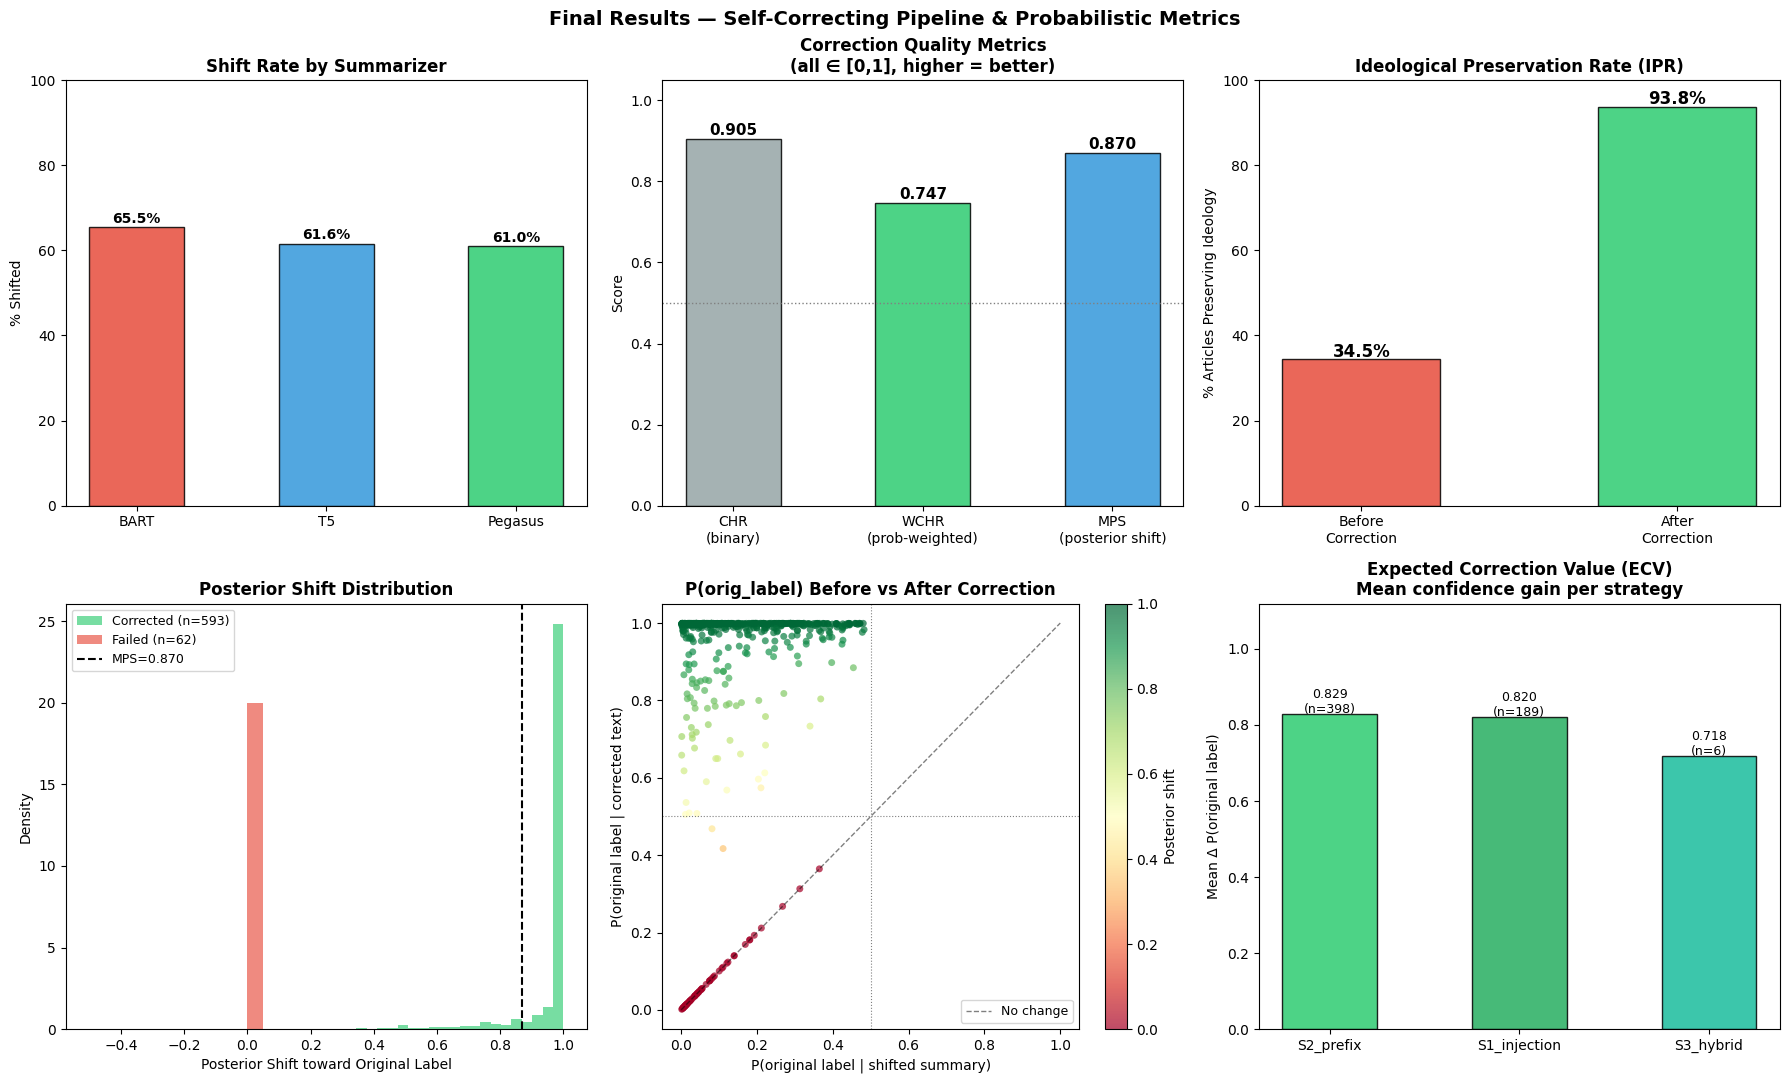

✅ Saved final_results.png


In [24]:
import numpy as np

total_shifted   = len(corr_df)
corrected_count = (corr_df['status'] == 'corrected').sum()
failed_count    = (corr_df['status'] == 'correction_failed').sum()
total_articles  = len(sample_df)
stable_count    = (sample_df['shift_BART'] == False).sum()

# ── Classic CHR (kept for comparison) ─────────────────────────────
CHR        = corrected_count / total_shifted if total_shifted > 0 else 0
IPR_before = stable_count / total_articles
IPR_after  = (stable_count + corrected_count) / total_articles

# ── WCHR: Weighted Corrected Hit Ratio ────────────────────────────
# Each corrected article is weighted by the probability GAIN it achieved
# for the original label, rather than getting a flat 1/0 credit.
# WCHR ∈ [0, 1] where 1 means every shifted article was restored to
# full confidence in the original label.
#
# Formula:  WCHR = Σ max(0, Δp_i) / N_shifted
#   where Δp_i = P(orig_label | corrected_i) − P(orig_label | shifted_i)
#
# Why better than CHR:
#   - A correction that raises P(Left) from 0.51→0.99 scores higher
#     than one that only gets 0.51→0.52, even if both flip the label.
#   - Failed corrections with partial movement (e.g. 0.30→0.45) get
#     partial credit instead of zero, reflecting genuine improvement.
WCHR = corr_df['conf_gain'].clip(lower=0).sum() / total_shifted if total_shifted > 0 else 0

# ── Mean Posterior Shift (MPS) ────────────────────────────────────
# MPS = average normalised probability shift toward original label.
# posterior_shift_i = Δp_i / (1 − p_orig_before_i)
# Interpretation: 0 = no movement at all, 1 = perfect recovery.
# Captures partial recoveries that CHR and WCHR might under-value.
MPS = corr_df['posterior_shift'].mean()

# ── Expected Correction Value per strategy (ECV) ──────────────────
# For each strategy: mean conf_gain when the strategy succeeded.
# Tells you not just HOW OFTEN a strategy works but HOW MUCH it moves
# the needle when it does.
ecv_rows = []
for strat, grp in corr_df[corr_df['status']=='corrected'].groupby('strategy_used'):
    ecv_rows.append({
        'strategy': strat,
        'n_successes': len(grp),
        'mean_conf_gain': grp['conf_gain'].mean(),
        'mean_posterior_shift': grp['posterior_shift'].mean(),
    })
ecv_df = pd.DataFrame(ecv_rows).sort_values('mean_conf_gain', ascending=False)

print('=' * 65)
print('📊 FINAL RESULTS — AllSides + PoliticalBERT')
print('=' * 65)
print(f'Classifier:                {MODEL_NAME}')
print(f'Classifier F1 (macro):     {results["eval_f1_macro"]:.3f}')
print(f'Classifier Accuracy:       {results["eval_accuracy"]:.3f}')
print(f'Total articles analyzed:   {total_articles}')
for mkey in model_keys:
    sr = sample_df[f'shift_{mkey}'].mean() * 100
    print(f'  Shift rate ({mkey}):      {sr:.1f}%')
print()
print(f'── Correction metrics ──────────────────────────────────')
print(f'  CHR  (classic, binary):     {CHR:.3f}  ({CHR*100:.1f}%)')
print(f'  WCHR (prob-weighted):        {WCHR:.3f}  ← primary metric')
print(f'  MPS  (mean posterior shift): {MPS:.3f}')
print(f'  IPR before correction:       {IPR_before:.3f}')
print(f'  IPR after  correction:       {IPR_after:.3f}')
print(f'  IPR improvement:             +{(IPR_after-IPR_before)*100:.1f} pp')
print()
if len(ecv_df) > 0:
    print('── Expected Correction Value by strategy ───────────────')
    print(ecv_df.to_string(index=False))
print('=' * 65)

# ═══ Visualization ════════════════════════════════════════════════
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 11))
fig3.suptitle('Final Results — Self-Correcting Pipeline & Probabilistic Metrics',
               fontsize=14, fontweight='bold')

# 3a: Shift rate bars
ax = axes3[0, 0]
ax.bar(model_keys, [sample_df[f'shift_{m}'].mean()*100 for m in model_keys],
       color=bar_colors, alpha=0.85, edgecolor='black', width=0.5)
for i, mkey in enumerate(model_keys):
    ax.text(i, sample_df[f'shift_{mkey}'].mean()*100 + 1,
            f"{sample_df[f'shift_{mkey}'].mean()*100:.1f}%",
            ha='center', fontweight='bold')
ax.set_title('Shift Rate by Summarizer', fontweight='bold')
ax.set_ylabel('% Shifted'); ax.set_ylim(0, 100)

# 3b: WCHR vs CHR comparison bar
ax = axes3[0, 1]
metric_names = ['CHR\n(binary)', 'WCHR\n(prob-weighted)', 'MPS\n(posterior shift)']
metric_vals  = [CHR, WCHR, MPS]
bar_colors_m = ['#95a5a6', '#2ecc71', '#3498db']
bars_m = ax.bar(metric_names, metric_vals, color=bar_colors_m, alpha=0.85, edgecolor='black', width=0.5)
for bar, val in zip(bars_m, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title('Correction Quality Metrics\n(all ∈ [0,1], higher = better)', fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

# 3c: IPR before/after
ax = axes3[0, 2]
bars3c = ax.bar(['Before\nCorrection', 'After\nCorrection'],
                [IPR_before*100, IPR_after*100],
                color=['#e74c3c', '#2ecc71'], alpha=0.85, width=0.5, edgecolor='black')
for bar, val in zip(bars3c, [IPR_before*100, IPR_after*100]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Ideological Preservation Rate (IPR)', fontweight='bold')
ax.set_ylabel('% Articles Preserving Ideology')

# 3d: Posterior shift distribution (histogram)
ax = axes3[1, 0]
corrected_ps = corr_df[corr_df['status'] == 'corrected']['posterior_shift']
failed_ps    = corr_df[corr_df['status'] != 'corrected']['posterior_shift']
ax.hist(corrected_ps, bins=20, alpha=0.65, color='#2ecc71',
        label=f'Corrected (n={len(corrected_ps)})', density=True)
ax.hist(failed_ps,    bins=20, alpha=0.65, color='#e74c3c',
        label=f'Failed (n={len(failed_ps)})',    density=True)
ax.axvline(MPS, color='black', linestyle='--', linewidth=1.5, label=f'MPS={MPS:.3f}')
ax.set_title('Posterior Shift Distribution', fontweight='bold')
ax.set_xlabel('Posterior Shift toward Original Label')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# 3e: Confidence gain scatter (p_before vs p_after)
ax = axes3[1, 1]
sc = ax.scatter(corr_df['p_orig_before'], corr_df['p_orig_after'],
                c=corr_df['posterior_shift'], cmap='RdYlGn',
                vmin=0, vmax=1, alpha=0.7, s=25, edgecolors='none')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='No change')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8)
plt.colorbar(sc, ax=ax, label='Posterior shift')
ax.set_title('P(orig_label) Before vs After Correction', fontweight='bold')
ax.set_xlabel('P(original label | shifted summary)')
ax.set_ylabel('P(original label | corrected text)')
ax.legend(fontsize=9)

# 3f: Per-strategy ECV bar
ax = axes3[1, 2]
if len(ecv_df) > 0:
    strat_colors = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085'][:len(ecv_df)]
    bars_ecv = ax.bar(ecv_df['strategy'], ecv_df['mean_conf_gain'],
                      color=strat_colors, alpha=0.85, edgecolor='black', width=0.5)
    for bar, row_e in zip(bars_ecv, ecv_df.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{row_e.mean_conf_gain:.3f}\n(n={row_e.n_successes})',
                ha='center', fontsize=9)
    ax.set_title('Expected Correction Value (ECV)\nMean confidence gain per strategy',
                 fontweight='bold')
    ax.set_ylabel('Mean Δ P(original label)')
    ax.set_ylim(0, max(ecv_df['mean_conf_gain']) * 1.35)
else:
    ax.text(0.5, 0.5, 'No corrected articles', ha='center', transform=ax.transAxes)
    ax.set_title('Expected Correction Value (ECV)', fontweight='bold')

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved final_results.png')


## ✍️ CELL 14 — Manual Verification Export (50 Articles)

In [30]:
shifted_b   = sample_df[sample_df['shift_BART'] == True]
not_shifted = sample_df[sample_df['shift_BART'] == False]

manual_sample = pd.concat([
    shifted_b.sample(min(35, len(shifted_b)), random_state=42),
    not_shifted.sample(min(15, len(not_shifted)), random_state=42)
]).reset_index(drop=True)

manual_export = manual_sample[[
    TEXT_COL, 'text', 'filename',
    'summary_BART', 'summary_T5', 'summary_Pegasus',
    LABEL_COL, 'original_pred', 'original_conf',
    'pred_BART', 'conf_BART', 'pred_T5', 'conf_T5', 'pred_Pegasus', 'conf_Pegasus',
    'shift_BART', 'shift_T5', 'shift_Pegasus'
]].copy()

manual_export['manual_original_label'] = ''
manual_export['manual_summary_label']  = ''
manual_export['notes'] = ''

manual_export.to_csv('manual_verification_50.csv', index=False)
print('✅ Saved manual_verification_50.csv')
from google.colab import files
files.download('manual_verification_50.csv')

✅ Saved manual_verification_50.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 💾 CELL 15 — Save All Outputs + Paper Stats JSON

In [31]:
import json

sample_df.to_csv('full_results.csv', index=False)
corr_df.to_csv('correction_results.csv', index=False)
triggers_df.to_csv('trigger_points.csv', index=False)

strategy_breakdown = corr_df[corr_df['status']=='corrected']['strategy_used'].value_counts().to_dict()

paper_stats = {
    'dataset': 'PoliticalBias_AllSides_Txt',
    'classifier_model': MODEL_NAME,
    'n_train': len(train_df),
    'n_val':   len(val_df),
    'n_test':  len(test_df),
    'n_pseudo_source_groups': int(df_clean['pseudo_source'].nunique()),
    'classifier_accuracy':    float(results['eval_accuracy']),
    'classifier_f1_macro':    float(results['eval_f1_macro']),
    'classifier_f1_weighted': float(results['eval_f1_weighted']),
    'classifier_f1_left':     float(results['eval_f1_left']),
    'classifier_f1_center':   float(results['eval_f1_center']),
    'classifier_f1_right':    float(results['eval_f1_right']),
    'sample_size_analyzed':   total_articles,
    'shift_rate_BART':    float(sample_df['shift_BART'].mean()),
    'shift_rate_T5':      float(sample_df['shift_T5'].mean()),
    'shift_rate_Pegasus': float(sample_df['shift_Pegasus'].mean()),
    'n_trigger_sentences': len(triggers_df),
    'CHR':  float(CHR),
    'IPR_before': float(IPR_before),
    'IPR_after':  float(IPR_after),
    'IPR_improvement_pp': float((IPR_after - IPR_before) * 100),
    'strategy_breakdown': strategy_breakdown,
    'corrected_count': int(corrected_count),
    'failed_count':    int(failed_count),
}

with open('paper_stats.json', 'w') as f:
    json.dump(paper_stats, f, indent=2)

print('✅ All outputs saved:')
for fname in ['full_results.csv','correction_results.csv','trigger_points.csv',
              'paper_stats.json','eda_analysis.png','classifier_diagnostics.png',
              'shift_analysis.png','confidence_analysis.png','final_results.png']:
    try:
        from google.colab import files
        files.download(fname)
        print(f'  ✓ {fname}')
    except Exception as e:
        print(f'  ✗ {fname}: {e}')


✅ All outputs saved:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ full_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ confidence_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ final_results.png
